In [10]:
import torch

dataset = torch.load(f'dim2d_nx256_N2000_solver=exponax_nu0.000_t20.0_dict_ntimepoints21_batch0_all_frames.pt', weights_only=False)
print(dataset.keys())
print(dataset["x"].shape)
print(dataset["y"].shape)
test_dataset = torch.load(f'../dim2d_nx256_N50_solver=exponax_nu0.000_t20.0_test_all_frames.pt', weights_only=False)
print(test_dataset.keys())
print(test_dataset["x"].shape)
print(test_dataset["y"].shape)
train_dataset = torch.load(f'../dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt', weights_only=False)
print(train_dataset.keys())
print(train_dataset["x"].shape)
print(train_dataset["y"].shape)

dict_keys(['x', 'y', 'metadata'])
torch.Size([2000, 256, 256])
torch.Size([2000, 256, 256, 21])
dict_keys(['x', 'y', 'metadata'])
torch.Size([50, 256, 256])
torch.Size([50, 256, 256, 21])
dict_keys(['x', 'y', 'metadata'])
torch.Size([1150, 256, 256])
torch.Size([1150, 256, 256, 21])


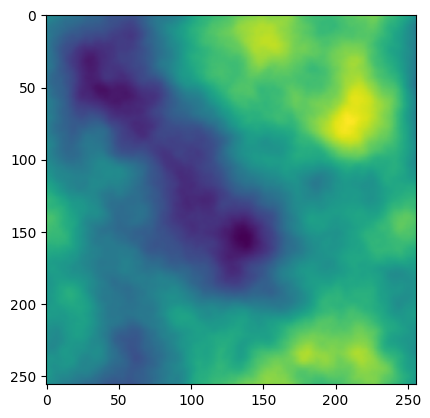

In [9]:
import matplotlib.pyplot as plt

plt.imshow(dataset["x"][1151])

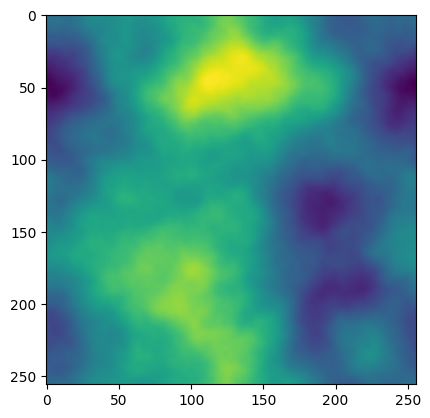

In [8]:
plt.imshow(dataset["x"][0])

In [2]:
dataset["x"][0]

tensor([[-0.1301, -0.1342, -0.1364,  ..., -0.1294, -0.1286, -0.1284],
        [-0.1262, -0.1289, -0.1307,  ..., -0.1304, -0.1285, -0.1263],
        [-0.1223, -0.1234, -0.1237,  ..., -0.1316, -0.1280, -0.1246],
        ...,
        [-0.1460, -0.1476, -0.1508,  ..., -0.1383, -0.1403, -0.1433],
        [-0.1391, -0.1414, -0.1445,  ..., -0.1353, -0.1354, -0.1367],
        [-0.1336, -0.1380, -0.1402,  ..., -0.1303, -0.1300, -0.1310]])

In [12]:
from tqdm import tqdm

# Combine train and test x
train_test_x = torch.cat([train_dataset['x'], test_dataset['x']], dim=0)

# Initialize a dictionary to track duplicates
duplicates = {}

# Compare each sample in train_test against all samples in dataset
for i in tqdm(range(len(train_test_x)), desc="Checking train/test samples"):
    current_sample = train_test_x[i]
    
    # Compare with all samples in main dataset with progress bar
    for j in tqdm(range(len(dataset['x'])), desc=f"Comparing sample {i}", leave=False):
        if torch.allclose(current_sample, dataset['x'][j], atol=1e-8):
            duplicates[f"train_test_{i}"] = f"dataset_{j}"
            print(f"\nFound duplicate: train/test sample {i} matches dataset sample {j}")
            break  # Stop checking after first match

if not duplicates:
    print("\nNo identical tensors found between train+test and main dataset")
else:
    print(f"\nFound {len(duplicates)} duplicate pairs:")
    for k, v in duplicates.items():
        print(f"{k} matches {v}")

Checking train/test samples:   0%|          | 0/1200 [00:00<?, ?it/s]

Checking train/test samples:   0%|          | 0/1200 [00:49<?, ?it/s]


KeyboardInterrupt: 

In [13]:
duplicates

{}